# 线性回归的从零开始实现
23级大数据管理与应用 谢嘉峻


In [2]:
import torch
import random
from d2l import torch as d2l

## 生成数据集

In [3]:
def synthetic_dat(w, b, numexamples):
    # 生成 y = Xw + b + 噪声
    X = torch.normal(0, 1, (numexamples, len(w)))
    y = torch.matmul(X, w) + b
    y += torch.normal(0, 0.01, y.shape)
    return X, y.reshape((-1, 1))

In [4]:
true_w = torch.tensor([1.5, -5])
true_b = 3
features, labels = synthetic_dat(true_w, true_b, 2000)

In [5]:
print('features', features[0], '\nlabel:', labels[0])

features tensor([1.7061, 1.1644]) 
label: tensor([-0.2492])


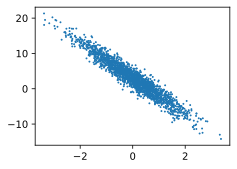

In [6]:
d2l.set_figsize()
d2l.plt.scatter(features[:, 1].detach().numpy(), labels.detach().numpy(), 1);

## 读取数据集

In [7]:
def data_iter(batch_size, features, labels):
    num_examples = len(features)
    indices = list(range(num_examples))
    # 随机读取
    random.shuffle(indices)
    for i in range(0, num_examples, batch_size):
        batch_indices = torch.tensor(
            indices[i: min(i + batch_size, num_examples)]
        )
        yield features[batch_indices], labels[batch_indices]

In [8]:
batch_size = 20

for X, y in data_iter(batch_size, features, labels):
    print(X, '\n', y)
    break

tensor([[ 0.5528, -0.1211],
        [-0.5223, -1.2150],
        [ 1.0663,  1.3738],
        [-1.9771, -0.5569],
        [ 0.1408, -0.4511],
        [-0.0673,  1.9424],
        [ 0.3331,  2.2074],
        [ 0.1190,  1.9644],
        [-1.6601, -0.5675],
        [ 0.1401, -0.7187],
        [-0.7500,  1.4587],
        [-0.3963, -0.0150],
        [-1.9560,  0.1966],
        [ 0.9621, -0.9185],
        [ 0.9271,  1.3140],
        [ 0.9645,  0.1981],
        [-1.6929, -0.6892],
        [ 0.7050,  1.6766],
        [-0.5965, -0.3738],
        [-1.1887,  1.9495]]) 
 tensor([[ 4.4272],
        [ 8.2881],
        [-2.2556],
        [ 2.8340],
        [ 5.4554],
        [-6.8143],
        [-7.5483],
        [-6.6399],
        [ 3.3434],
        [ 6.8099],
        [-5.4229],
        [ 2.4906],
        [-0.9231],
        [ 9.0336],
        [-2.1827],
        [ 3.4537],
        [ 3.8998],
        [-4.3254],
        [ 3.9850],
        [-8.5232]])


## 初始化模型参数

In [9]:
w = torch.normal(0, 0.01, size=(2,1), requires_grad=True)
b = torch.zeros(1, requires_grad=True)

## 定义模型

In [10]:
def linreg(X, w, b):
    return torch.matmul(X, w) + b

## 定义损失函数

In [11]:
def squared_loss(y_hat, y):  
    return (y_hat - y.reshape(y_hat.shape)) ** 2 / 2

## 定义优化算法

In [12]:
def sgd(params, lr, batch_size):
    with torch.no_grad():
        for param in params:
            param -= lr * param.grad / batch_size
            param.grad.zero_()

## 训练

In [13]:
lr = 0.03
num_epochs = 6
net = linreg
loss = squared_loss

In [14]:
for epoch in range(num_epochs):
    for X, y in data_iter(batch_size, features, labels):
        l = loss(net(X, w, b), y)  # X和y的小批量损失
        # 因为l形状是(batch_size,1)，而不是一个标量。l中的所有元素被加到一起，
        # 并以此计算关于[w,b]的梯度
        l.sum().backward()
        sgd([w, b], lr, batch_size)  # 使用参数的梯度更新参数
    with torch.no_grad():
        train_l = loss(net(features, w, b), labels)
        print(f'epoch {epoch + 1}, loss {float(train_l.mean()):f}')

epoch 1, loss 0.040377
epoch 2, loss 0.000145
epoch 3, loss 0.000051
epoch 4, loss 0.000051
epoch 5, loss 0.000051
epoch 6, loss 0.000051


In [15]:
print(f"估计的w: {w.reshape(true_w.shape)}")
print(f"估计的b: {b}")

print(f'w的估计误差: {true_w - w.reshape(true_w.shape)}')
print(f'b的估计误差: {true_b - b}')

估计的w: tensor([ 1.5002, -5.0001], grad_fn=<ViewBackward0>)
估计的b: tensor([3.0002], requires_grad=True)
w的估计误差: tensor([-2.1493e-04,  5.6267e-05], grad_fn=<SubBackward0>)
b的估计误差: tensor([-0.0002], grad_fn=<RsubBackward1>)
